# Classification Metrics: Confusion Matrix, Precision, Recall, F1 and ROC

> 📖 Book: [ch07 – Classification metrics](../../.claude/skills/ml-knowledge/chapters/ch07-classification-metrics.md) · Prev: [02_logistic_regression/04](../02_logistic_regression/04_one_vs_all.ipynb) · Next: [04_neural_networks](../04_neural_networks/01_forward_propagation.ipynb)

## Why accuracy is not enough

Suppose 1 % of patients have a disease. A "classifier" that always answers *healthy* has **99 % accuracy** and is useless. With **skewed classes** we need metrics that look at the positive class separately.

## The confusion matrix

Compare predictions $\hat y$ with the truth $y$ (positive = 1 = the rare/interesting class):

| | predicted $\hat y = 0$ | predicted $\hat y = 1$ |
|---|:---:|:---:|
| **actual $y = 0$** | TN (true negative) | FP (false positive, type I error) |
| **actual $y = 1$** | FN (false negative, type II error) | TP (true positive) |

From it:

$$
\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{precision } P = \frac{TP}{TP + FP} \quad \text{(of what I flagged as positive, how much was right?)}
$$

$$
\text{recall } R = \frac{TP}{TP + FN} \quad \text{(of the actual positives, how many did I catch?)} \quad = \text{sensitivity} = \text{TPR}
$$

$$
\text{specificity} = \frac{TN}{TN + FP}, \qquad \text{FPR} = 1 - \text{specificity} = \frac{FP}{FP + TN}
$$

**Which one matters?**

- **Recall** when a false negative is intolerable: disease screening, fraud, safety faults.
- **Precision** when a false positive is intolerable: spam filtering (losing a real email), recommending an expensive treatment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics as skm
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from ml import metrics
from ml.features.scaling import standardize
from ml.linear_models import add_bias
from ml.logistic import fit_logistic, predict_proba

plt.style.use("seaborn-v0_8-whitegrid")

# Imbalanced problem: ~7 % positives
X, y = make_classification(n_samples=3000, n_features=6, n_informative=4, weights=[0.93], class_sep=0.8, random_state=4)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
Ztr, transform = standardize(Xtr)
theta, _ = fit_logistic(add_bias(Ztr), ytr, alpha=1.0)
scores = predict_proba(theta, add_bias(transform(Xte)))
print(f"positives in test set: {yte.mean():.1%}")

positives in test set: 7.4%


always predict 0                 acc=0.926  P=0.000  R=0.000  F1=0.000
logistic regression, gamma=0.5   acc=0.959  P=0.935  R=0.483  F1=0.637


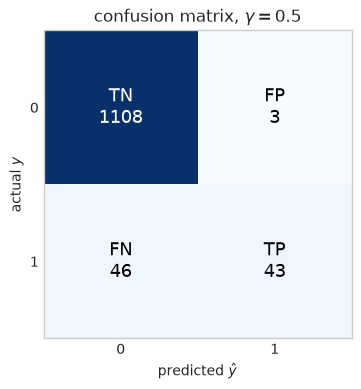

In [2]:
def report(name, y_pred):
    print(f"{name:32s} acc={metrics.accuracy(yte, y_pred):.3f}  P={metrics.precision(yte, y_pred):.3f}  "
          f"R={metrics.recall(yte, y_pred):.3f}  F1={metrics.f1(yte, y_pred):.3f}")


report("always predict 0", np.zeros_like(yte))
report("logistic regression, gamma=0.5", (scores >= 0.5).astype(int))

cm = metrics.confusion_matrix(yte, scores >= 0.5)
assert np.array_equal(cm, skm.confusion_matrix(yte, scores >= 0.5))  # same convention as sklearn
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{['TN', 'FP', 'FN', 'TP'][2 * i + j]}\n{v}", ha="center", va="center", fontsize=13,
            color="white" if v > cm.max() / 2 else "black")
ax.set(xticks=[0, 1], yticks=[0, 1], xlabel=r"predicted $\hat y$", ylabel="actual $y$", title=r"confusion matrix, $\gamma = 0.5$")
ax.grid(False)
plt.show()

The trivial classifier has excellent accuracy but zero recall. Logistic regression has similar accuracy but actually finds positives.

## The precision–recall trade-off

The threshold $\gamma$ controls the balance:

- **raise $\gamma$** (predict 1 only when very confident) → fewer FP, **higher precision, lower recall**;
- **lower $\gamma$** (don't miss any positive) → fewer FN, **higher recall, lower precision**.

## $F_1$ score

To compare classifiers with a single number, the arithmetic mean $(P + R)/2$ is a bad idea: predicting everything positive gives $R = 1$ and scores $\ge 0.5$. The **$F_1$ score** is the harmonic mean,

$$
F_1 = 2\frac{PR}{P + R},
$$

which is high only if **both** $P$ and $R$ are high (it is dominated by the smaller one). More generally $F_\beta = (1 + \beta^2)\frac{PR}{\beta^2P + R}$ weighs recall $\beta$ times as much as precision.

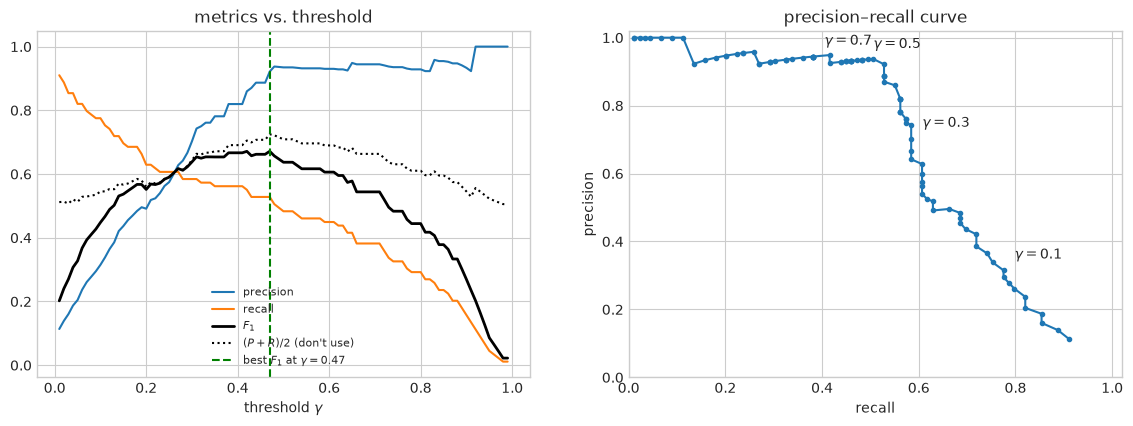

logistic regression, gamma=0.47  acc=0.962  P=0.922  R=0.528  F1=0.671


In [3]:
gammas = np.linspace(0.01, 0.99, 99)
P = np.array([metrics.precision(yte, scores >= g) for g in gammas])
R = np.array([metrics.recall(yte, scores >= g) for g in gammas])
F = np.array([metrics.f1(yte, scores >= g) for g in gammas])
g_best = gammas[np.argmax(F)]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(gammas, P, label="precision")
ax[0].plot(gammas, R, label="recall")
ax[0].plot(gammas, F, "k", lw=2, label="$F_1$")
ax[0].plot(gammas, (P + R) / 2, "k:", label="$(P+R)/2$ (don't use)")
ax[0].axvline(g_best, c="g", ls="--", label=rf"best $F_1$ at $\gamma = {g_best:.2f}$")
ax[0].set(xlabel=r"threshold $\gamma$", title="metrics vs. threshold")
ax[0].legend(fontsize=8)

ax[1].plot(R, P, ".-")
for g in (0.1, 0.3, 0.5, 0.7):
    i = np.argmin(abs(gammas - g))
    ax[1].annotate(rf"$\gamma={g}$", (R[i], P[i]), xytext=(8, 8), textcoords="offset points")
ax[1].set(xlabel="recall", ylabel="precision", title="precision–recall curve", xlim=(0, 1.02), ylim=(0, 1.02))
plt.show()
report(f"logistic regression, gamma={g_best:.2f}", (scores >= g_best).astype(int))

## ROC curve and AUC

The **ROC curve** plots the true positive rate (recall) against the false positive rate for every threshold. A random classifier lies on the diagonal; a perfect one hugs the top-left corner. The **area under the curve (AUC)** summarizes it: the probability that a random positive gets a higher score than a random negative. It is threshold-independent, which makes it good for comparing models. With heavily imbalanced data, the precision–recall curve is often more informative, since the huge number of TN keeps the FPR small.

AUC (ml.metrics) = 0.8733 | sklearn = 0.8733


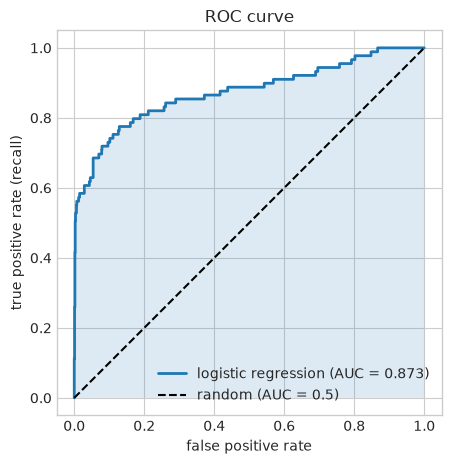

In [4]:
fpr, tpr, _ = metrics.roc_curve(yte, scores)
area = metrics.auc(fpr, tpr)
print(f"AUC (ml.metrics) = {area:.4f} | sklearn = {skm.roc_auc_score(yte, scores):.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, lw=2, label=f"logistic regression (AUC = {area:.3f})")
ax.fill_between(fpr, tpr, alpha=0.15)
ax.plot([0, 1], [0, 1], "k--", label="random (AUC = 0.5)")
ax.set(xlabel="false positive rate", ylabel="true positive rate (recall)", title="ROC curve", aspect="equal")
ax.legend(loc="lower right")
plt.show()

## Summary

| Metric | Formula | Use when |
|---|---|---|
| Accuracy | $(TP+TN)/m$ | classes balanced, errors equally costly |
| Precision | $TP/(TP+FP)$ | false positives are expensive |
| Recall | $TP/(TP+FN)$ | false negatives are expensive |
| $F_1$ | $2PR/(P+R)$ | one number, imbalanced data, unsure which error matters more |
| ROC-AUC | area under TPR vs FPR | compare models across all thresholds |

Build the confusion matrix first; choose $\gamma$ on a validation set, not on the test set.